In [495]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [496]:
df = pd.read_csv(r'C:\K\social-media-dev-crawler\data\Lda\validated_sample.csv.csv')

In [497]:
df.head()

,id,site,old_topic,new_topic,old_veredict,Coluna 6,is_valid_2,technologies,subtopics,link,is_valid1,is_valid2
0,13817452,stackoverflow,"Binary/Data Encoding, Strings, and Hashing in ...",Random Number Generation & Entropy,False,True,True,"SQL server, generation random number",Generating Cryptographic Keys and Unique Rando...,https://stackoverflow.com/questions/13817452,NaN,NaN
1,88430,crypto,"Binary/Data Encoding, Strings, and Hashing in ...",File Encryption & Data Processing,False,True,True,"Python Decrypt files, XOR",Programmatic File Encryption and Decryption Is...,https://crypto.stackexchange.com/questions/88430,NaN,NaN
2,6317276,stackoverflow,"Binary/Data Encoding, Strings, and Hashing in ...",String/Byte-Level Encryption & Encoding,True,True,True,"MD5, hash","String–Byte Conversion, Encoding, and Hashing ...",https://stackoverflow.com/questions/6317276,NaN,NaN
3,2532668,stackoverflow,"Binary/Data Encoding, Strings, and Hashing in ...",String/Byte-Level Encryption & Encoding,True,True,True,"C#, encryption XOR",General Q&A on String Encryption/Decryption in...,https://stackoverflow.com/questions/2532668,NaN,NaN
4,26217076,stackoverflow,"Binary/Data Encoding, Strings, and Hashing in ...",Hash Functions & Collision Properties,True,True,True,"MD5, hash","Hash Output Size, Collisions, and Uniqueness",https://stackoverflow.com/questions/26217076,NaN,NaN


## Topics

In [498]:
df.groupby('new_topic')['is_valid_2'].mean()

new_topic
Block Cipher Modes & Message Encryption                    0.840000
Certificates, PKI, and Server Authentication               0.705882
Crypto Code Implementation & Library Issues                0.932432
Device and Storage Encryption                              0.833333
File Encryption & Data Processing                          1.000000
General Cryptography Concepts & Security Discussions       1.000000
Hash Functions & Collision Properties                      1.000000
Key Strength, Attacks & Brute-Force Security               0.777778
Number Theory & Performance in Cryptographic Algorithms    0.947368
Password Hashing, Salting & Cracking Defense               0.944444
Public-Key Cryptography & Key Exchange                     0.875000
Q&A Meta-Discussion (StackOverflow Mechanics)              0.000000
Random Number Generation & Entropy                         0.909091
String/Byte-Level Encryption & Encoding                    0.826087
User Data Protection & Password Handli

## Tecnologies

In [499]:
import re
import pandas as pd

def encontrar_linguagem_robusta(tags_texto, linguagens_alvo):
    """
    Verifica se alguma linguagem alvo está presente na string de tags,
    usando uma regex robusta para lidar com caracteres especiais (+, #).
    """
    if pd.isna(tags_texto) or not tags_texto.strip():
        return 'N/A'

    tags_texto_lower = tags_texto.lower()

    for lang in linguagens_alvo:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)
        
        regex_busca = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'
    
        if re.search(regex_busca, tags_texto_lower):
            return lang
            
    return 'N/A'

In [500]:
LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Go', 'Perl', 'Ruby']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

df['language'] = df['technologies'].str.lower().apply(
    lambda x: encontrar_linguagem_robusta(x, LANGUAGES)
)

In [501]:
df['language'].value_counts() / df.shape[0] * 100

language
N/A           57.190635
Java          14.046823
C#            11.036789
JavaScript     4.682274
PHP            4.682274
Python         3.678930
C++            2.341137
C              1.003344
Go             0.668896
Perl           0.334448
Ruby           0.334448
Name: count, dtype: float64

<Axes: ylabel='language'>

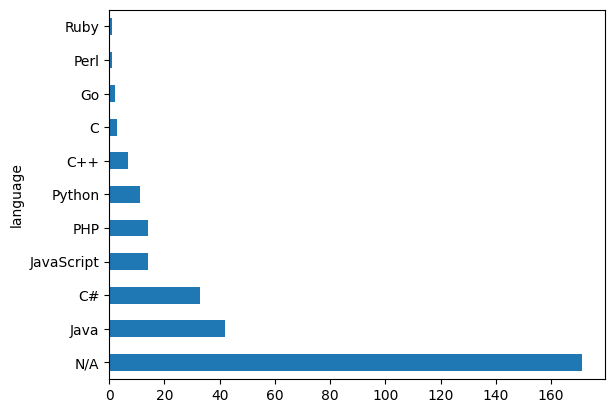

In [502]:
df['language'].value_counts().plot.barh()

In [503]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove as linguagens especificadas da string de tecnologias.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'N/A'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    # Join back
    return ', '.join(filtered_list) if filtered_list else 'N/A'

# Remove languages from technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [504]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)

In [505]:
contagem_palavras_clean = exploded.value_counts()
contagem_palavras_clean.head(10)

technologies_clean
aes           79
rsa           39
n/a           23
encryption    20
openssl       17
sha           15
md5           12
hash          11
hmac          11
base64         9
Name: count, dtype: int64

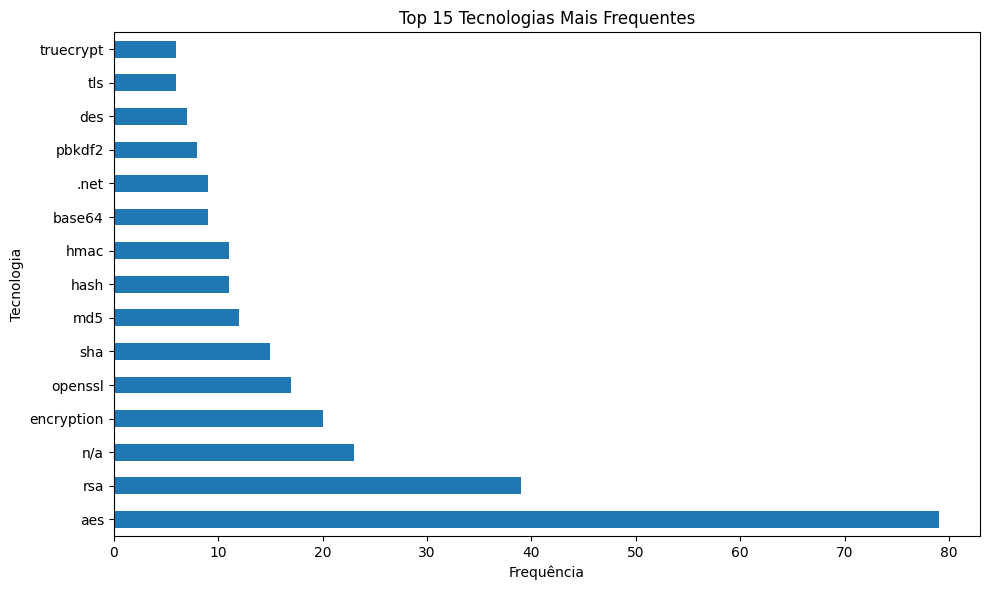

In [506]:
contagem_palavras_clean.head(15).plot.barh(figsize=(10, 6))
plt.title('Top 15 Tecnologias Mais Frequentes')
plt.xlabel('Frequência')
plt.ylabel('Tecnologia')
plt.tight_layout()
plt.show()

In [507]:
pd.set_option('display.max_rows', None)

In [508]:
contagem_palavras_clean / df.shape[0] * 100

technologies_clean
aes                             26.421405
rsa                             13.043478
n/a                              7.692308
encryption                       6.688963
openssl                          5.685619
sha                              5.016722
md5                              4.013378
hash                             3.678930
hmac                             3.678930
base64                           3.010033
.net                             3.010033
pbkdf2                           2.675585
des                              2.341137
tls                              2.006689
truecrypt                        2.006689
cryptojs                         1.672241
sql server                       1.672241
ssl                              1.672241
block-cipher                     1.672241
pgp                              1.337793
file-encryption                  1.337793
bouncycastle                     1.337793
iv                               1.337793
bcrypt         